In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
df=pd.read_csv("insurance.csv")

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1338, 7)

In [ ]:
df['region'].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.isnull().sum().sum()

np.int64(0)

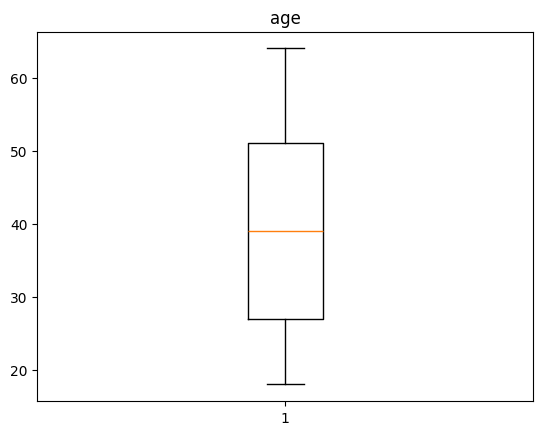

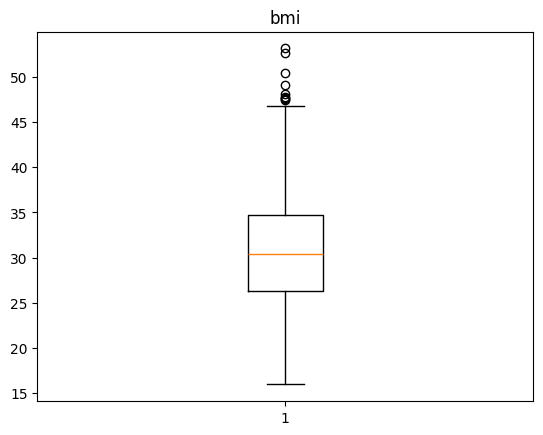

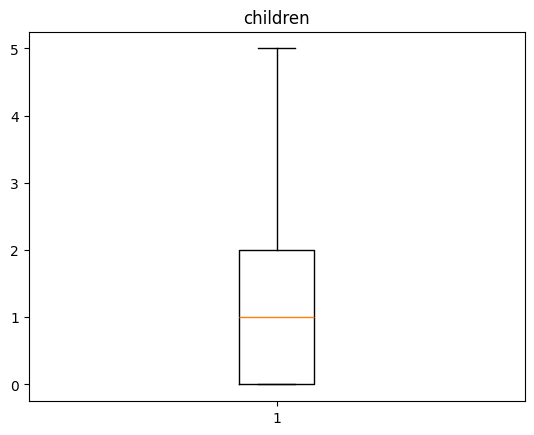

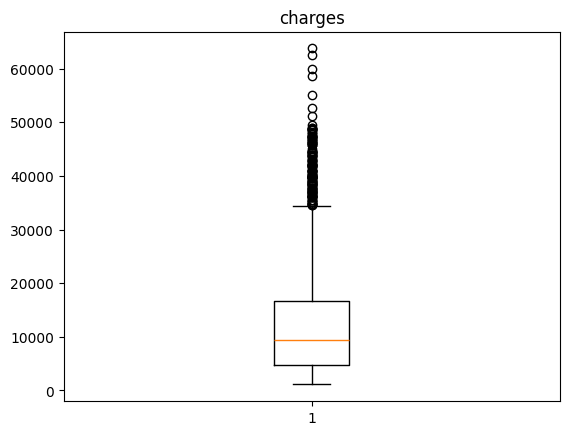

In [ ]:
for col in df.select_dtypes(include=np.number).columns:
  plt.boxplot(df[col])
  plt.title(col)
  plt.show()

In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df = df.drop_duplicates()

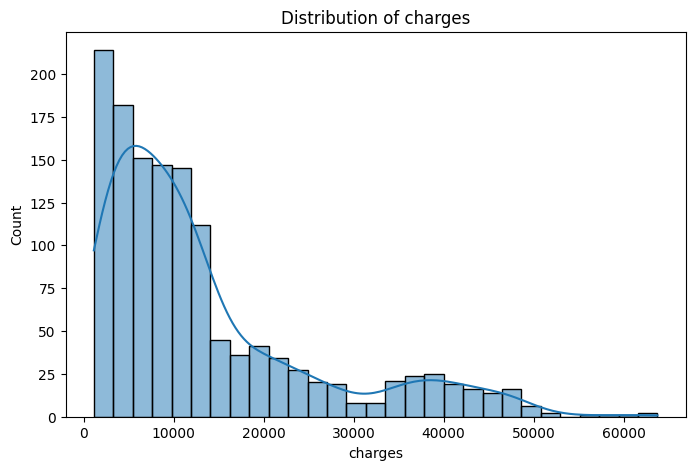

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['charges'],kde=True)
plt.title("Distribution of charges")
plt.show()

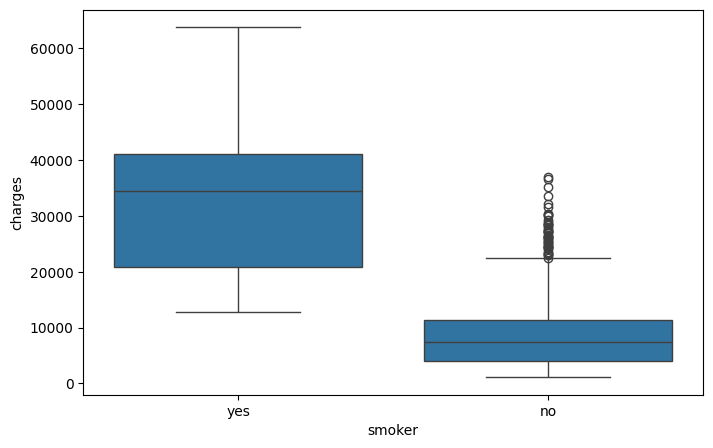

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='smoker',y='charges',data=df)
plt.show()

<Axes: xlabel='sex', ylabel='charges'>

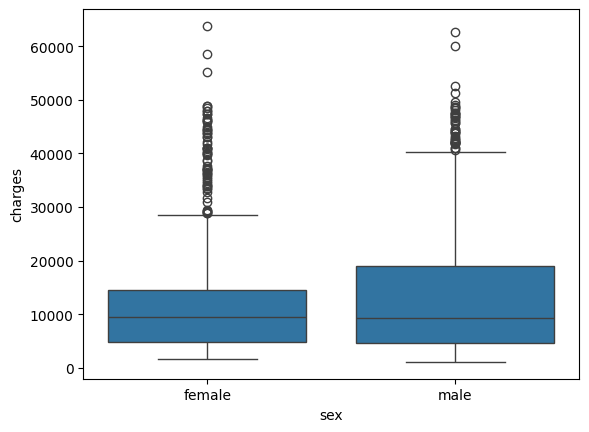

In [ ]:
sns.boxplot(x="sex", y="charges", data=df)

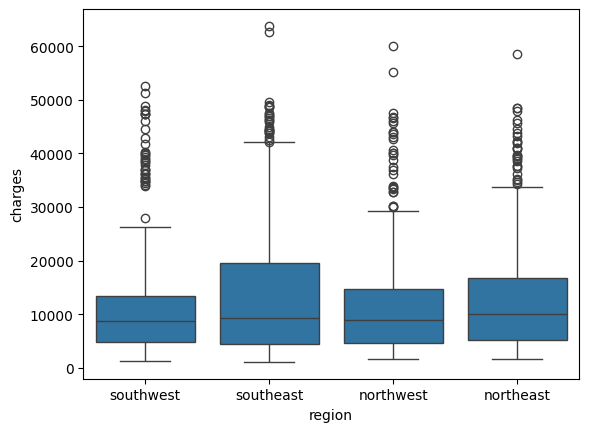

In [ ]:
sns.boxplot(x="region", y="charges", data=df)
plt.show()

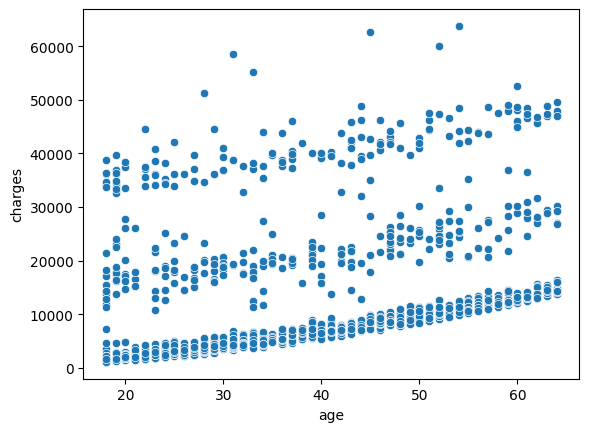

In [ ]:
sns.scatterplot(x='age',y='charges',data=df)
plt.show()

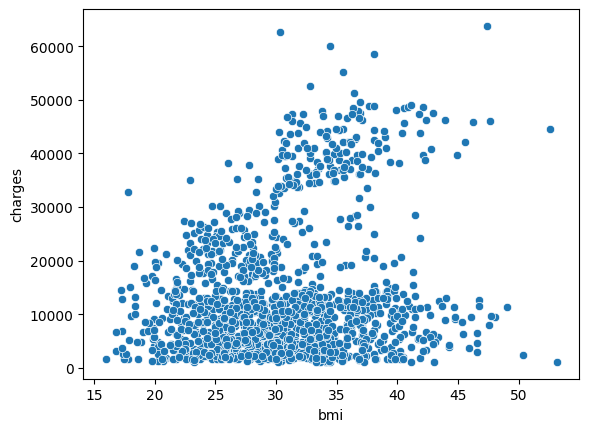

In [ ]:
sns.scatterplot(x="bmi", y="charges", data=df)
plt.show()

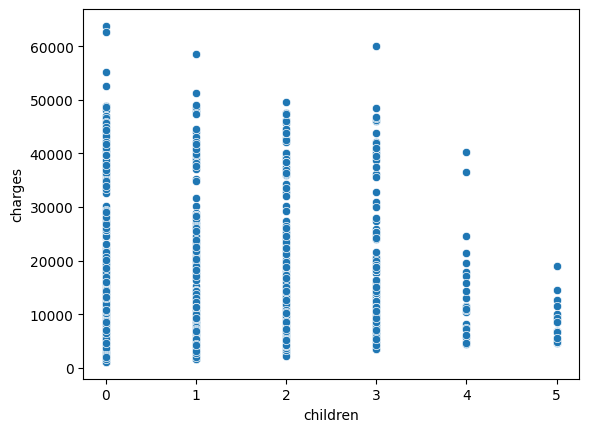

In [ ]:
sns.scatterplot(x="children", y="charges", data=df)
plt.show()

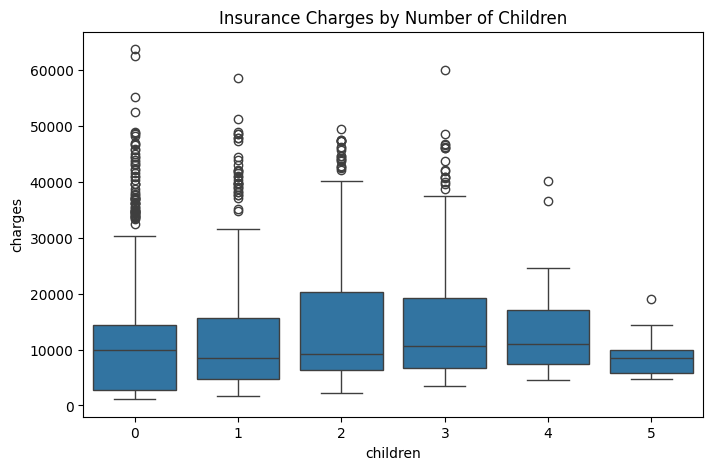

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="children", y="charges", data=df)
plt.title("Insurance Charges by Number of Children")
plt.show()

In [ ]:
correlation=df.corr(numeric_only=True)['charges'].sort_values(ascending=False)

In [ ]:
correlation

,charges
charges,1.000000
age,0.298308
bmi,0.198401
children,0.067389


In [ ]:
X=df.drop('charges',axis=1)
y=df['charges']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [ ]:
X=pd.get_dummies(X,drop_first=True).astype(int)

In [ ]:
X

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,0,1,0,0,1
1,18,33,1,1,0,0,1,0
2,28,33,3,1,0,0,1,0
3,33,22,0,1,0,1,0,0
4,32,28,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...
1333,50,30,3,1,0,1,0,0
1334,18,31,0,0,0,0,0,0
1335,18,36,0,0,0,0,1,0
1336,21,25,0,0,0,0,0,1


In [ ]:
scaler=StandardScaler()

In [ ]:
# First, one-hot encode the categorical columns in X_train and X_test
X_train = pd.get_dummies(X_train, drop_first=True).astype(int)
X_test = pd.get_dummies(X_test, drop_first=True).astype(int)

# Define the list of numerical columns that should be scaled.
# 'age', 'bmi', and 'children' are the continuous/discrete numerical features that benefit from scaling.
# The 'region' column is now represented by dummy variables after one-hot encoding and is typically not scaled further.
cols_to_scale = ['age', 'bmi','children']

# Now apply the scaler to these identified numerical columns
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [ ]:
model=LinearRegression()

In [ ]:
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE : 4171.78317351056
MSE : 35475116.828216426
RMSE: 5956.099128474645
R2 Score: 0.8069445108473701


In [ ]:
ridge=Ridge(alpha=1.0)
ridge.fit(X_train,y_train)
ridge_pred=ridge.predict(X_test)

In [ ]:
print("MAE :", mean_absolute_error(y_test, ridge_pred))
print("MSE :", mean_squared_error(y_test, ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("R2 Score:", r2_score(y_test, ridge_pred))


MAE : 4188.60284151068
MSE : 35660655.53823706
RMSE: 5971.654338475818
R2 Score: 0.805934809692805


In [ ]:
lasso=Lasso(alpha=10)
lasso.fit(X_train,y_train)
lasso_pred=lasso.predict(X_test)

In [ ]:
print("MAE :", mean_absolute_error(y_test, lasso_pred))
print("MSE :", mean_squared_error(y_test, lasso_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))
print("R2 Score:", r2_score(y_test, lasso_pred))


MAE : 4178.8923981906555
MSE : 35632415.10273243
RMSE: 5969.289329788968
R2 Score: 0.8060884940659003


In [ ]:
import joblib

In [ ]:
joblib.dump(model,"insurance_model.pkl")

['insurance_model.pkl']

In [ ]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [ ]:
joblib.dump(X_train.columns,"columns.pkl")

['columns.pkl']

In [ ]:
import pickle

pickle.dump(model, open("insurance_model.pkl","wb"))

In [ ]:
pickle.dump(scaler,open("scaler.pkl", "wb"))

In [ ]:
pickle.dump(X_train.columns, open("columns.pkl","wb"))